In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df=pd.concat([pd.read_csv('train.csv').drop(columns=['Survived']), pd.read_csv('test.csv')])

In [ ]:
df.shape


(1309, 11)

In [5]:
df=df.sample(1309)

# Single sample t test

In [6]:
# take out 25 sample as if we have only 25 data point now we try to do hypothesis testing 
sample=df['Age'].sample(25)

In [ ]:
# I am hypothesizing that the average age of people in titanic was 35
#H0 will be average age of people in titanic is 35
#H1 will be average age of people in titanic is not 35(2 tails test)


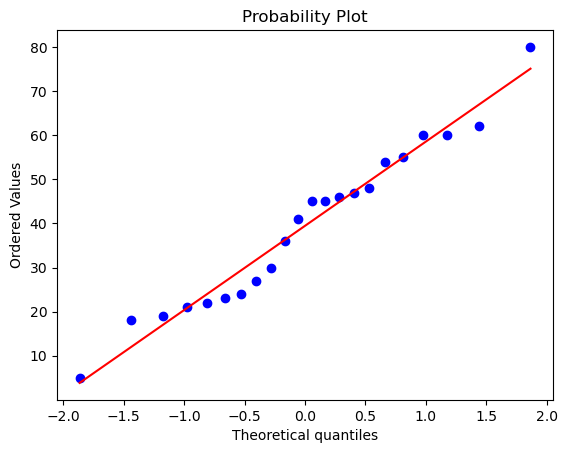

In [17]:
# as my sample size is less than 30 we need to check normality
# QQ plot, histogram, kde plot,shapiro test

#QQ plot
stats.probplot(sample.dropna(),dist='norm', plot=plt)
plt.show()

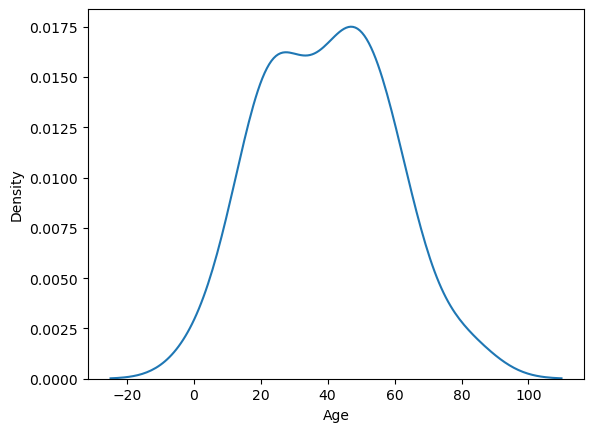

In [19]:
# kde
sns.kdeplot(sample.dropna())
plt.show()

In [21]:
#shapiro test
stat,p=stats.shapiro(sample.dropna())
if p>0.05:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")

Data follows a normal distribution


In [ ]:
# sample data is normal so apply one sample t test
#Severe non-normality + small sample → use Wilcoxon signed-rank test instead of one-sample t-test
# population mean we are checking for is 35
t_stat,p=stats.ttest_1samp(sample,35)

alpha=0.05
# dividing p/2 because 2  tailed test
if p/2 < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Fail to reject the null hypothesis.


# Independent 2 sample t test
# as we are checking if both sample are normaly distributed or not ,if sample size small and data is not normally distributed Mann–Whitney or transformation or bootstrap 
# if both are normaly distributed then check variance using laven test then decide equal variance or not

In [ ]:
# we are assuming that avg age of male is significantly higher than avg age of female
#H0 will be avg age of male is equal to avg age of female
# H1 will be avg age of male is not equal to avg age of female

In [43]:
male_age=df[df['Sex']=='male']['Age'].dropna()
female_age=df[df['Sex']=='female']['Age'].dropna()

In [65]:
#taking sample from male and female
male_sample=male_age.sample(25)
female_sample=female_age.sample(25)

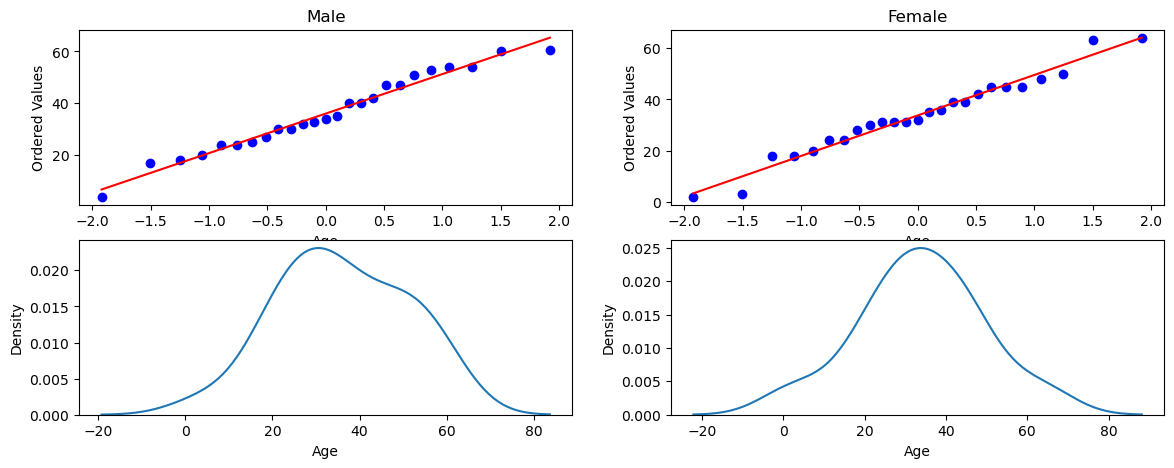

In [66]:
fig,axes = plt.subplots(2,2,figsize=(14,5))
stats.probplot(male_sample.dropna(),dist='norm',plot=axes[0,0])
stats.probplot(female_sample.dropna(),dist='norm',plot=axes[0,1])

sns.kdeplot(male_sample,ax=axes[1,0])
sns.kdeplot(female_sample,ax=axes[1,1])
axes[0,0].set_title('Male')
axes[0,1].set_title('Female')
axes[0,0].set_xlabel('Age')
axes[0,1].set_xlabel('Age')
axes[1,0].set_xlabel('Age')
axes[1,1].set_xlabel('Age')
plt.show()

In [67]:
def perform_shapiro_test(sample_data):

    stat, p_value = stats.shapiro(sample_data)
    alpha = 0.05
    print("p-value:", p_value)
    if p>0.05:
        print("Data follows a normal distribution")
    else:
        print("Data does not follow a normal distribution")
    

In [68]:
perform_shapiro_test(male_sample.dropna())
perform_shapiro_test(female_sample.dropna())

p-value: 0.7078611149007853
Data follows a normal distribution
p-value: 0.7086585654026889
Data follows a normal distribution


In [69]:
male_sample.skew()

np.float64(-0.071633077121135)

In [70]:
female_sample.skew()

np.float64(-0.10190440491407499)

In [71]:
# skewness is small and visual inspection through KDE and Q-Q plots suggest the feature is approximately normal 

from scipy.stats import levene
stat, p = levene(male_sample, female_sample)

print(f"Levene Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# Interpretation
alpha = 0.05

if p > alpha:
    print("\nEqual variance assumption satisfied")
    print("→ Use standard independent t-test (equal_var=True)")
else:
    print("\nEqual variance assumption violated")
    print("→ Use Welch's t-test (equal_var=False)")

Levene Statistic: 0.0171
P-value: 0.8965

Equal variance assumption satisfied
→ Use standard independent t-test (equal_var=True)


In [72]:
from scipy.stats import ttest_ind

alpha = 0.05
t_stat, p = ttest_ind(
        male_sample,
        female_sample,
        equal_var=True
    )

if p/2 < alpha:
    print("\nReject H0")
    print("There is a statistically significant difference between the group means")
else:
    print("\nFail to reject H0")
    print("No statistically significant difference between the group means")


Fail to reject H0
No statistically significant difference between the group means


In [73]:
print(male_age.mean()-female_age.mean())

1.8981403346598569


# Paired (Dependent) T-test

In [74]:
before = np.array([80, 92, 75, 68, 85, 78, 73, 90, 70, 88, 76, 84, 82, 77, 91])
after = np.array([78, 93, 81, 67, 88, 76, 74, 91, 69, 88, 77, 81, 80, 79, 88])

In [81]:
# H0: There is no significant difference between the group means(before and after)
# H1: There is a significant difference between the group means(before and after)

In [82]:
diff=before-after # the diffrence between before and after should follow a normal distribution


Difference normal?
      ↓
    Yes
      ↓
Paired t-test

    No
      ↓

Sample size large?
     ↓          ↓
   Yes         No
     ↓          ↓
t-test often   Wilcoxon signed-rank
still robust   test

<Axes: ylabel='Density'>

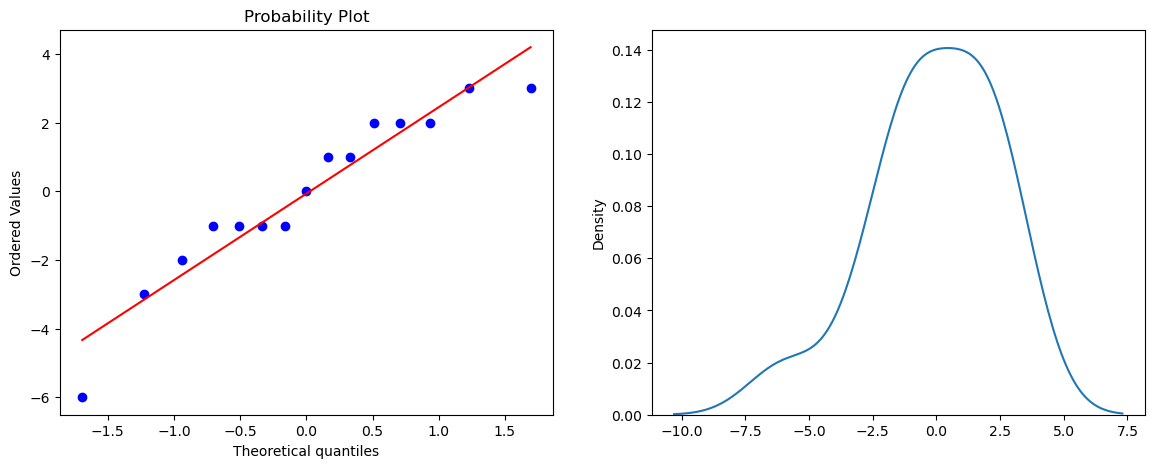

In [77]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
stats.probplot(diff,dist='norm',plot=axes[0])
sns.kdeplot(diff)

In [78]:
t_stat, p =stats.shapiro(diff)
if p>0.05:
    print("Data follows a normal distribution")
else:
    print("Data does not follow a normal distribution")

Data follows a normal distribution


In [79]:
from scipy.stats import ttest_rel

alpha = 0.05
t_stat, p = ttest_rel(before, after)

if p/2 < alpha:
    print("\nReject H0")
    print("There is a statistically significant difference between the group means")
else:
    print("\nFail to reject H0")
    print("No statistically significant difference between the group means")


Fail to reject H0
No statistically significant difference between the group means


In [80]:
after.mean()-before.mean()  

np.float64(0.06666666666667709)